# Portfolio Optimizer — Linear Algebra Approach
**Flow:** Stock prices → Returns matrix R → Covariance Σ → Eigendecomposition → Lagrangian → Efficient Frontier → Optimal Portfolios

# Mathematical Foundation

This notebook builds a **Vietnam stock portfolio optimizer** using linear algebra. The objective is: *given an investor's target return r\*, find the portfolio with the minimum possible risk that achieves exactly r\*.*

---

## 1. From Prices to Returns

We work with **log returns** rather than raw prices, because log returns are time-additive and approximately normally distributed.

$$R_{t,i} = \ln\!\left(\frac{P_{t,i}}{P_{t-1,i}}\right)$$

- **R** is a **T × n** matrix — T trading days, n stocks
- Each column is one stock's daily return history
- **Intuition**: if a stock goes from 100 to 105, the log return is ln(1.05) ≈ 4.88% — close to the simple return for small moves, but mathematically cleaner

---

## 2. EWMA — Exponentially Weighted Moving Average

Recent market conditions matter more than history from 5 years ago. EWMA assigns exponentially decaying weights to past observations.

$$\lambda = e^{-\ln 2 \,/\, h}, \qquad h = 252 \text{ trading days}$$

A day *k* periods ago receives weight proportional to $\lambda^k$. With h = 252, an observation one year ago carries **half** the weight of today.

- Data from 2018 receives < 0.01% weight — past crises (COVID, 2022 bond scandal) fade to near zero
- **Intuition**: like human memory — recent events feel more relevant than distant ones

---

## 3. Expected Returns Vector **μ**

$$\hat{\mu}_i = \left(\sum_{t=1}^{T} \lambda^{T-t} R_{t,i}\right) \times 252$$

- **μ** is an **n × 1** vector — one annualised expected return per stock
- Estimated purely from historical returns — a weighted average of what each stock *has done*
- **Key limitation**: estimation error is large. SE(μ̂ᵢ) ≈ σᵢ / √T_eff ≈ ±29% annual per stock. A stock showing μ = 30% could truly be anywhere from 1% to 59%
- **Intuition**: μ is our best guess at future returns, but it is a noisy guess

---

## 4. Covariance Matrix **Σ**

$$\hat{\Sigma} = \operatorname{EWMA-Cov}(R) \times 252$$

- **Σ** is an **n × n** symmetric positive semi-definite matrix
- Entry Σᵢⱼ measures how stocks i and j move together
- Diagonal Σᵢᵢ = variance of stock i (volatility squared)
- **Reliably estimated** from history — correlations between stocks are structurally persistent
- **Intuition**: Σ captures the wiring of the market — which stocks move together and by how much. Unlike μ, this is stable enough to trust

---

## 5. Eigendecomposition — Spectral Theorem

Because **Σ** is symmetric, it can be decomposed into orthogonal components:

$$\Sigma = Q \Lambda Q^{\top}$$

- **Q** = orthogonal matrix of eigenvectors — each column is an independent risk direction
- **Λ** = diagonal matrix of eigenvalues λ₁ ≥ λ₂ ≥ … ≥ λₙ — variance in each direction
- **Largest eigenvalue** → the market factor (all stocks rising/falling together)
- **Smallest eigenvalues** → stock-specific noise, can be diversified away
- **Intuition**: eigendecomposition rotates the portfolio into independent bets. Instead of thinking about 39 correlated stocks, we work with 39 uncorrelated risk directions

**Marchenko–Pastur threshold** separates genuine risk from estimation noise:

$$\lambda_+ = \frac{\left(1 + \sqrt{\gamma}\right)^2}{T}, \qquad \gamma = \frac{n}{T}$$

Eigenvalues below λ₊ carry no real market information — they are statistical artefacts

---

## 6. Input Regularisation — Two Independent Layers

μ is noisy and Σ can be ill-conditioned. We apply one fix per input before optimising.

**μ-side: James-Stein shrinkage**

$$\hat{\mu}^{JS} = \bar{\mu} + \alpha\,(\hat{\mu} - \bar{\mu}), \qquad \alpha = \max\!\left(0,\ 1 - \frac{(n-2)\cdot\overline{\mathrm{SE}^2}}{\|\hat{\mu} - \bar{\mu}\|^2}\right)$$

- Pulls all μ estimates toward the cross-sectional mean
- α is self-calibrating: high noise → small α (aggressive shrinkage), low noise → α near 1 (keep the estimates)
- **Intuition**: if one stock shows 103% expected return, ask whether you really believe it or whether it is noise. James-Stein automatically discounts outliers proportional to the overall noise level

**Σ-side: Tikhonov (L2) regularisation**

$$\Sigma_{\text{reg}} = \Sigma + \lambda I \;\equiv\; Q(\Lambda + \lambda I)Q^{\top}$$

- Lifts every eigenvalue by λ — prevents near-zero eigenvalues from destabilising the solver
- Equivalent to adding λ · ‖w‖² = λ · HHI to the objective — penalises concentration directly
- **Intuition**: a covariance matrix with tiny eigenvalues is like a nearly-flat landscape — the optimizer can wander far in those directions at no apparent cost. λI adds a gentle slope everywhere, keeping weights grounded

---

## 7. Targeted Minimum Variance Portfolio

The core problem: given target return r\*, find the weights that minimise portfolio risk.

$$\min_{w}\; w^{\top} \Sigma_{\text{reg}}\, w \quad \text{s.t.} \quad \boldsymbol{\mu}^{\top}w = r^*, \quad \mathbf{1}^{\top}w = 1, \quad 0 \leq w_i \leq 0.15$$

- **μᵀw = r\*** — the portfolio must hit the investor's target return exactly
- **1ᵀw = 1** — fully invested, no cash or leverage
- **0 ≤ wᵢ ≤ 0.15** — long-only (Vietnam market rules), 15% per-position cap
- Solved via **SLSQP** (Sequential Least Squares Programming) — handles all constraints natively
- Portfolio variance = $w^{\top}\Sigma\, w$, volatility = $\sqrt{w^{\top}\Sigma\, w}$ (reported with original Σ, not Σ_reg)
- **Intuition**: among all portfolios that return exactly r\*, pick the one that fluctuates least. This is the investor's best option because it achieves their goal with the least uncertainty

The **efficient frontier** is the set of targeted minimum variance portfolios swept across all feasible return levels from the GMV floor to the reliable ceiling.

---

## 8. Concentration Risk — HHI & Reliable Zone

Not all frontier points are equally trustworthy. We measure concentration using the **Herfindahl–Hirschman Index**:

$$\text{HHI} = \sum_{i=1}^{n} w_i^2, \qquad N_{\text{eff}} = \frac{1}{\text{HHI}}$$

- **N_eff = 1** → all money in one stock (maximum concentration)
- **N_eff = n** → equal-weight portfolio (minimum concentration)
- **Reliable zone**: N_eff ≥ 3 — enough diversification for individual μ errors to partially cancel
- **Caution zone**: N_eff < 3 — the solution is driven by 1–2 stocks whose μ we cannot trust
- **Intuition**: if a portfolio behaves like 2 stocks, you are not optimising — you are guessing which 2 stocks will perform. The math is correct; the inputs are not

**User input constraint:**

$$r_{\text{GMV}} \leq r^* \leq r_{\text{reliable\ max}}$$

- Below r_GMV: mathematically infeasible — no long-only portfolio can achieve this return
- Above r_reliable_max: solvable but μ-driven — concentration risk dominates

## Cell 1 — Install Dependencies
Run this cell first to install all required packages into your current Python kernel.

In [105]:
import subprocess, sys

packages = ['numpy', 'pandas', 'matplotlib', 'yfinance', 'scipy']
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('All packages installed — proceed to the next cell.')

All packages installed — proceed to the next cell.


In [106]:
# Core numerical and data libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse

# Yahoo Finance for fetching stock prices
try:
    import yfinance as yf
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'yfinance'])
    import yfinance as yf

print('All libraries loaded.')

All libraries loaded.


# Data selection

In [107]:
import yfinance as yf
import pandas as pd
import os

# ======================
# PHASE 1 — CANDIDATE POOL
# Wide net: 8-12 candidates per sector, ~120 total
# After download we keep only those with data from 2018 and <3% missing
# ======================
CANDIDATES = {
    "Banking":          ["VCB","BID","MBB","CTG","VPB","ACB","STB","LPB","SHB","EIB"],
    "Real Estate":      ["VHM","VIC","KDH","NLG","DXG","VRE","NVL","PDR","BCM","TDC"],
    "Consumer":         ["MSN","VNM","SAB","MCH","KDC","ANV","QNS"],
    "Securities":       ["SSI","VCI","HCM","VND","SHS","MBS","CTS"],
    "Logistics":        ["GMD","VTP","SCS","HAH","PVT","VSC","STG"],
    "Energy":           ["GAS","NT2","POW","REE","PC1","GEX","QTP"],
    "Steel":            ["HPG","HSG","NKG","SMC","TLH","VGS"],
    "Aviation":         ["VJC","HVN","ACV"],
    "Construction":     ["CTD","HHV","FCN","HBC","LCG","VCG","CII"],
    "Technology":       ["FPT","ELC","CTR","CMG","ITD","SGT","VGI"],
    "Oil & Gas":        ["PLX","PVD","PVS","OIL","PVC","CNG"],
    "Chemicals":        ["DGC","DCM","DPM","BFC","CSV","LAS","SFG"],
    "Retail":           ["MWG","FRT","PNJ","DGW"],
    "Insurance":        ["BVH","BMI","MIG","PTI","PVI","BIC"],
    "Textile":          ["TCM","STK","TNG","ADS","VGT","MSH","GIL"],
    "Pharma":           ["DHG","IMP","TRA","DMC","PME","OPC"],
    "Automotive":       ["HAX","SVC","CSM","VEA","SRC"],
    "Agriculture":      ["DBC","HAG","PAN","HNG","VFG","LSS","BAF"],
}

all_candidates  = [t for ts in CANDIDATES.values() for t in ts]
candidate_tickers = [t + ".VN" for t in all_candidates]

# Build reverse map: ticker → sector (used later for balanced selection)
ticker_sector = {t: s for s, ts in CANDIDATES.items() for t in ts}

print(f"Total candidates : {len(all_candidates)}")
print(f"Sectors          : {len(CANDIDATES)}\n")
for sector, ts in CANDIDATES.items():
    print(f"  {sector:<18} ({len(ts):>2})  {ts}")

Total candidates : 119
Sectors          : 18

  Banking            (10)  ['VCB', 'BID', 'MBB', 'CTG', 'VPB', 'ACB', 'STB', 'LPB', 'SHB', 'EIB']
  Real Estate        (10)  ['VHM', 'VIC', 'KDH', 'NLG', 'DXG', 'VRE', 'NVL', 'PDR', 'BCM', 'TDC']
  Consumer           ( 7)  ['MSN', 'VNM', 'SAB', 'MCH', 'KDC', 'ANV', 'QNS']
  Securities         ( 7)  ['SSI', 'VCI', 'HCM', 'VND', 'SHS', 'MBS', 'CTS']
  Logistics          ( 7)  ['GMD', 'VTP', 'SCS', 'HAH', 'PVT', 'VSC', 'STG']
  Energy             ( 7)  ['GAS', 'NT2', 'POW', 'REE', 'PC1', 'GEX', 'QTP']
  Steel              ( 6)  ['HPG', 'HSG', 'NKG', 'SMC', 'TLH', 'VGS']
  Aviation           ( 3)  ['VJC', 'HVN', 'ACV']
  Construction       ( 7)  ['CTD', 'HHV', 'FCN', 'HBC', 'LCG', 'VCG', 'CII']
  Technology         ( 7)  ['FPT', 'ELC', 'CTR', 'CMG', 'ITD', 'SGT', 'VGI']
  Oil & Gas          ( 6)  ['PLX', 'PVD', 'PVS', 'OIL', 'PVC', 'CNG']
  Chemicals          ( 7)  ['DGC', 'DCM', 'DPM', 'BFC', 'CSV', 'LAS', 'SFG']
  Retail             ( 4)  ['M

## Phase 2 — Download All Candidates (2018–2026)
Download the full candidate pool. Quality filtering happens next — no manual curation here.

In [108]:
START = "2018-01-01"
END   = "2026-04-21"

raw = yf.download(
    candidate_tickers,
    start=START,
    end=END,
    auto_adjust=True,
    threads=True,
    progress=True
)

# Rename by ticker name, not position (yfinance returns alphabetically)
ticker_to_stock = dict(zip(candidate_tickers, all_candidates))
close_raw = raw["Close"].rename(columns=ticker_to_stock)

print(f"\nDate range : {START} → {END}")
print(f"Raw shape  : {close_raw.shape}  ({close_raw.shape[0]} days × {close_raw.shape[1]} tickers)")

failed_dl = close_raw.columns[close_raw.isna().all()].tolist()
if failed_dl:
    print(f"⚠ Failed downloads (all NaN): {failed_dl}")

[****                   8%                       ]  9 of 119 completed$HNG.VN: possibly delisted; no timezone found
$PVC.VN: possibly delisted; no timezone found
[********              16%                       ]  19 of 119 completed$QTP.VN: possibly delisted; no timezone found
[********              17%                       ]  20 of 119 completed$SHS.VN: possibly delisted; no timezone found
[************          25%                       ]  30 of 119 completed$ACV.VN: possibly delisted; no timezone found
[****************      34%                       ]  40 of 119 completed$MBS.VN: possibly delisted; no timezone found
[********************  42%                       ]  50 of 119 completed$VGI.VN: possibly delisted; no timezone found
[**********************49%                       ]  58 of 119 completed$HBC.VN: possibly delisted; no timezone found
[**********************50%                       ]  59 of 119 completed$TNG.VN: possibly delisted; no timezone found
[******************


Date range : 2018-01-01 → 2026-04-21
Raw shape  : (2087, 119)  (2087 days × 119 tickers)
⚠ Failed downloads (all NaN): ['ACV', 'HBC', 'HNG', 'LAS', 'MBS', 'OIL', 'PME', 'PTI', 'PVC', 'PVI', 'PVS', 'QNS', 'QTP', 'SHS', 'TNG', 'VEA', 'VGI', 'VGS', 'VGT']


## Step 2 — Market Calendar Alignment
Remove phantom dates where only a handful of tickers have data (e.g. VTP on public holidays).  
A valid trading day requires ≥ 90% of tickers to have a Close price.

In [109]:
# Fix: use dropna(how='all') instead of 90% threshold
# The 90% threshold was dropping pre-listing dates for recently-listed stocks,
# collapsing 2087 days down to 677. A market holiday has ALL tickers missing —
# a pre-listing date has only that ticker missing, which is valid data.
close_cal = close_raw.dropna(how="all")   # remove only pure market holidays

removed = len(close_raw) - len(close_cal)
print(f"Raw dates      : {len(close_raw)}")
print(f"Market holidays: {removed}  (rows where every ticker had NaN)")
print(f"Valid dates    : {len(close_cal)}")
print(f"\nAligned shape  : {close_cal.shape}")

# Show per-ticker listing date (first non-NaN) so we know the effective overlap window
listing_dates = close_cal.apply(lambda col: col.first_valid_index())
print(f"\nPer-ticker listing date (earliest non-NaN):")
print(f"{'Ticker':<8} {'Listed':>12}")
print("-" * 22)
for stock, dt in sorted(listing_dates.items(), key=lambda x: x[1], reverse=True):
    print(f"{stock:<8} {str(dt.date()):>12}")

Raw dates      : 2087
Market holidays: 0  (rows where every ticker had NaN)
Valid dates    : 2087

Aligned shape  : (2087, 119)

Per-ticker listing date (earliest non-NaN):
Ticker         Listed
----------------------
ACV               NaT
ADS        2023-07-17
BCM        2023-07-17
BFC        2023-07-17
BVH        2023-07-17
CNG        2023-07-17
CSM        2023-07-17
CTR        2023-07-17
DCM        2023-07-17
DGC        2023-07-17
DHG        2023-07-17
DMC        2023-07-17
FCN        2023-07-17
GMD        2023-07-17
HAG        2023-07-17
NLG        2023-07-17
BAF        2021-12-03
BIC        2018-01-02
HBC               NaT
HNG               NaT
HSG        2023-07-17
HVN        2023-07-17
HHV        2022-01-20
CTS        2018-05-21
FRT        2018-04-26
ACB        2018-01-02
DXG        2018-01-02
HCM        2018-01-02
HPG        2018-01-02
IMP        2018-01-02
LAS               NaT
LPB        2020-11-09
GEX        2018-01-18
ANV        2018-01-02
BID        2018-01-02
BMI        2

## Step 3 — Data Quality Check
Flag tickers with too many missing days (Type 2 gaps: suspensions, late listings).  
Drop any ticker with > 3% missing — they will corrupt the covariance estimate.

In [110]:
CUTOFF_DATE      = "2019-01-01"   # must have data before this date to qualify
MISSING_MAX      = 0.03           # max 3% missing days

close_cal = close_raw.dropna(how="all")   # drop pure market holidays

# Per-ticker: first valid date and missing %
listing_dates = close_cal.apply(lambda col: col.first_valid_index())
missing_pct   = close_cal.isna().mean()

# Eligibility: data available before CUTOFF_DATE AND missing below threshold
eligible = {
    stock
    for stock in close_cal.columns
    if listing_dates[stock] is not None
    and listing_dates[stock] <= pd.Timestamp(CUTOFF_DATE)
    and missing_pct[stock] <= MISSING_MAX
}

print(f"Candidates downloaded : {len(close_cal.columns)}")
print(f"Eligible (data from before {CUTOFF_DATE}, <{MISSING_MAX*100:.0f}% missing): {len(eligible)}")
print()
print(f"{'Sector':<18}  {'Ticker':<6}  {'Data from':>12}  {'Missing%':>9}  {'Eligible'}")
print("-" * 62)

eligible_by_sector = {s: [] for s in CANDIDATES}
for sector, members in CANDIDATES.items():
    for stock in members:
        if stock not in close_cal.columns:
            continue
        first = listing_dates[stock]
        pct   = missing_pct[stock]
        ok    = stock in eligible
        if ok:
            eligible_by_sector[sector].append(stock)
        marker = "✓" if ok else "✗"
        reason = "" if ok else (
            "no data" if first is None else
            f"starts {first.date()}" if first > pd.Timestamp(CUTOFF_DATE) else
            f"{pct*100:.1f}% missing"
        )
        print(f"{sector:<18}  {stock:<6}  "
              f"{str(first.date()) if first else 'N/A':>12}  "
              f"{pct*100:>8.2f}%  {marker}  {reason}")

Candidates downloaded : 119
Eligible (data from before 2019-01-01, <3% missing): 48

Sector              Ticker     Data from   Missing%  Eligible
--------------------------------------------------------------
Banking             VCB       2018-01-02      0.91%  ✓  
Banking             BID       2018-01-02      0.91%  ✓  
Banking             MBB       2018-01-02      0.91%  ✓  
Banking             CTG       2018-01-02      0.91%  ✓  
Banking             VPB       2023-07-17     67.51%  ✗  starts 2023-07-17
Banking             ACB       2018-01-02      1.15%  ✓  
Banking             STB       2023-07-17     67.56%  ✗  starts 2023-07-17
Banking             LPB       2020-11-09     34.98%  ✗  starts 2020-11-09
Banking             SHB       2018-01-02      1.05%  ✓  
Banking             EIB       2018-01-02      1.01%  ✓  
Real Estate         VHM       2023-07-17     67.56%  ✗  starts 2023-07-17
Real Estate         VIC       2018-01-02      0.91%  ✓  
Real Estate         KDH       2018-01-

## Phase 3 — Balanced Universe Selection
From each sector's eligible tickers, pick the best 3 (fewest missing days).  
Sectors with fewer than 3 eligible tickers take what's available.

In [111]:
PICKS_PER_SECTOR = 3

selected = []
print(f"{'Sector':<18}  {'Selected':<30}  {'Note'}")
print("-" * 65)

for sector, pool in eligible_by_sector.items():
    # Sort by missing % ascending (fewest gaps first)
    ranked = sorted(pool, key=lambda t: missing_pct[t])
    picks  = ranked[:PICKS_PER_SECTOR]
    selected.extend(picks)

    n     = len(picks)
    note  = (f"✓ full"            if n == PICKS_PER_SECTOR else
             f"⚠ only {n} eligible" if n > 0 else
             "❌ none — sector excluded")
    print(f"{sector:<18}  {str(picks):<30}  {note}")

# Build final aligned DataFrame using only selected tickers
close_selected = close_cal[selected]
N         = len(selected)
T_total   = len(close_selected)
T_overlap = int(close_selected.dropna().shape[0])

print(f"\nFinal universe    : {N} tickers across {sum(1 for v in eligible_by_sector.values() if v)} sectors")
print(f"Trading days      : {T_total}")
print(f"Full-overlap days : {T_overlap}")
print(f"T/N ratio         : {T_overlap/N:.1f}  {'✓ Safe' if T_overlap/N >= 20 else '⚠ Apply Ledoit-Wolf'}")

Sector              Selected                        Note
-----------------------------------------------------------------
Banking             ['VCB', 'BID', 'MBB']           ✓ full
Real Estate         ['VIC', 'KDH', 'DXG']           ✓ full
Consumer            ['ANV', 'KDC', 'SAB']           ✓ full
Securities          ['VCI', 'SSI', 'HCM']           ✓ full
Logistics           ['HAH', 'PVT', 'VSC']           ✓ full
Energy              ['GAS', 'REE', 'PC1']           ✓ full
Steel               ['HPG', 'NKG']                  ⚠ only 2 eligible
Aviation            []                              ❌ none — sector excluded
Construction        ['CTD', 'LCG', 'CII']           ✓ full
Technology          ['FPT', 'CMG', 'ELC']           ✓ full
Oil & Gas           []                              ❌ none — sector excluded
Chemicals           ['DPM', 'CSV']                  ⚠ only 2 eligible
Retail              ['PNJ', 'DGW']                  ⚠ only 2 eligible
Insurance           ['BMI', 'BIC']       

## Step 4 — Forward-fill Type 2 Gaps & Export to CSV
Forward-fill gaps ≤ 5 consecutive days (short trading suspensions).  
Export one `.csv` file per ticker to `portfolio_data/raw/prices/`.

In [112]:
FFILL_LIMIT = 5

close_filled = close_selected.ffill(limit=FFILL_LIMIT)

output_dir = os.path.join("portfolio_data", "raw", "prices")
os.makedirs(output_dir, exist_ok=True)

success, failed = 0, []
for stock in close_filled.columns:
    try:
        df = close_filled[[stock]].rename(columns={stock: "Close"})
        df = df.dropna()
        df.index.name = "Date"

        path = os.path.join(output_dir, f"{stock}.csv")
        df.to_csv(path)
        success += 1
    except Exception as e:
        print(f"❌ {stock}: {e}")
        failed.append(stock)

print(f"✓ Saved {success} ticker files → {output_dir}/")
if failed:
    print(f"❌ Failed : {failed}")

✓ Saved 39 ticker files → portfolio_data/raw/prices/


In [113]:
print("=" * 50)
print("DATASET READY — VALIDATION SUMMARY")
print("=" * 50)

final_tickers = list(close_filled.columns)
N         = len(final_tickers)
T_total   = len(close_filled)
T_overlap = int(close_filled.dropna().shape[0])

print(f"Tickers kept      : {N}")
print(f"Total trading days: {T_total}")
print(f"Full-overlap days : {T_overlap}  (all {N} tickers present simultaneously)")
print(f"T/N ratio         : {T_overlap/N:.1f}  {'✓ Safe' if T_overlap/N >= 20 else '⚠ Too low — apply Ledoit-Wolf shrinkage'}")
print(f"Date range        : {close_filled.index[0].date()} → {close_filled.index[-1].date()}")
print(f"Output            : portfolio_data/raw/prices/  ({N} .csv files)")
print()

print(f"{'Ticker':<8} {'Days':>6}  {'Start':>12}  {'End':>12}")
print("-" * 44)
for stock in final_tickers:
    path = os.path.join("portfolio_data", "raw", "prices", f"{stock}.csv")
    df   = pd.read_csv(path, index_col="Date", parse_dates=["Date"])
    print(f"{stock:<8} {len(df):>6}  {str(df.index[0].date()):>12}  {str(df.index[-1].date()):>12}")

DATASET READY — VALIDATION SUMMARY
Tickers kept      : 39
Total trading days: 2087
Full-overlap days : 2086  (all 39 tickers present simultaneously)
T/N ratio         : 53.5  ✓ Safe
Date range        : 2018-01-02 → 2026-04-20
Output            : portfolio_data/raw/prices/  (39 .csv files)

Ticker     Days         Start           End
--------------------------------------------
VCB        2087    2018-01-02    2026-04-20
BID        2087    2018-01-02    2026-04-20
MBB        2087    2018-01-02    2026-04-20
VIC        2087    2018-01-02    2026-04-20
KDH        2087    2018-01-02    2026-04-20
DXG        2087    2018-01-02    2026-04-20
ANV        2087    2018-01-02    2026-04-20
KDC        2087    2018-01-02    2026-04-20
SAB        2087    2018-01-02    2026-04-20
VCI        2087    2018-01-02    2026-04-20
SSI        2087    2018-01-02    2026-04-20
HCM        2087    2018-01-02    2026-04-20
HAH        2087    2018-01-02    2026-04-20
PVT        2087    2018-01-02    2026-04-20
VSC 

---
## Processed Layer — Build R, μ, Σ, Q, Λ from 39 CSVs

Transform raw per-ticker CSV files into the numerical artifacts the KKT optimizer needs.  
Run **Steps 1 → 5** in order. After the initial build, the daily refresh pipeline at the bottom of this notebook recomputes processed/ automatically.

```
portfolio_data/
├── raw/prices/           ← 39 .csv files  (built above)
└── processed/
    ├── prices.npy         (T × N)   aligned, forward-filled price matrix
    ├── returns.npy        (T-1 × N) daily simple returns matrix R
    ├── mu.npy             (N,)      annualised expected return vector μ
    ├── sigma.npy          (N × N)   annualised covariance matrix Σ
    ├── eigenvalues.npy    (N,)      eigenvalues Λ, sorted descending
    ├── eigenvectors.npy   (N × N)   eigenvector matrix Q (columns = eigenvectors)
    ├── dates.npy          (T-1,)    ISO date strings for each row of R
    └── meta.json                    tickers list, shape, T/N ratio, last_updated
```

## Step 1 / 5 — Load Raw Prices → Aligned Price Matrix **P**

Read one CSV per ticker from `portfolio_data/raw/prices/`, align all tickers to a shared Vietnam market calendar, and stack into a price matrix.

$$P \in \mathbb{R}^{T_{\text{raw}} \times n}$$

- **T_raw** = raw calendar days in the date range (before cleaning)
- **n = 39** tickers across 13 HOSE/HNX sectors
- Phantom dates (days where < 10% of tickers have data) are dropped
- Forward-fill gaps ≤ 5 consecutive trading days (public holidays, thin-trading sessions)

This produces a clean, gap-free price matrix **P** that is the sole input to Step 2.

In [129]:
import numpy as np
import pandas as pd
import os, time

RAW_DIR       = os.path.join("portfolio_data", "raw", "prices")
PROCESSED_DIR = os.path.join("portfolio_data", "processed")
FFILL_LIMIT   = 5
TRADING_DAYS  = 252
HALFLIFE      = 252   # EWMA halflife in trading days (≈ 1 year)
                      # Effective sample size ≈ 357 days → T/N_eff ≈ 9.2
                      # Weight of 2018 data < 0.01% — ghost regimes fade to zero

os.makedirs(PROCESSED_DIR, exist_ok=True)

# ══════════════════════════════════════════════════════════
# STEP 1 / 5 — Load raw CSVs and build aligned price matrix
# ══════════════════════════════════════════════════════════
print("STEP 1 / 5 — Load & Align Prices")
print("─" * 50)
t0 = time.time()

csv_files = sorted(f for f in os.listdir(RAW_DIR) if f.endswith(".csv"))
tickers   = [f.replace(".csv", "") for f in csv_files]

frames = {}
for fname in csv_files:
    stock = fname.replace(".csv", "")
    df    = pd.read_csv(os.path.join(RAW_DIR, fname),
                        index_col="Date", parse_dates=["Date"])
    frames[stock] = df["Close"]

prices = pd.DataFrame(frames).sort_index()
prices = prices.dropna(how="all")          # drop pure market-holiday rows

T_raw, N = prices.shape
T_overlap = int(prices.dropna().shape[0])

print(f"  Tickers loaded     : {N}")
print(f"  Date range         : {prices.index[0].date()}  →  {prices.index[-1].date()}")
print(f"  Total trading days : {T_raw}")
print(f"  Full-overlap days  : {T_overlap}  (all {N} tickers present simultaneously)")
print(f"  T/N ratio          : {T_overlap/N:.1f}  {'✓ Safe (≥ 20)' if T_overlap/N >= 20 else '⚠ Below 20 — shrinkage needed'}")

missing_days = prices.isna().sum()
flagged = missing_days[missing_days > 0]
if flagged.empty:
    print(f"\n  Missing data       : none — all tickers fully populated")
else:
    print(f"\n  Missing data per ticker (after initial ffill in raw export):")
    print(f"  {'Ticker':<8}  {'Days':>6}  {'Pct':>7}")
    print(f"  {'-'*25}")
    for tk, m in flagged.items():
        print(f"  {tk:<8}  {m:>6}  {m/T_raw*100:>6.2f}%")

print(f"\n  ✓ Step 1 done  ({time.time()-t0:.2f}s)")
print(f"  → prices  shape: {prices.shape}")

STEP 1 / 5 — Load & Align Prices
──────────────────────────────────────────────────
  Tickers loaded     : 39
  Date range         : 2018-01-02  →  2026-04-24
  Total trading days : 2091
  Full-overlap days  : 2090  (all 39 tickers present simultaneously)
  T/N ratio          : 53.6  ✓ Safe (≥ 20)

  Missing data per ticker (after initial ffill in raw export):
  Ticker      Days      Pct
  -------------------------
  DBC            1    0.05%

  ✓ Step 1 done  (0.25s)
  → prices  shape: (2091, 39)


## Step 2 / 5 — Log Returns Matrix **R**

Convert the aligned price matrix into daily log returns.

$$R_{t,i} = \ln\!\left(\frac{P_{t,i}}{P_{t-1,i}}\right), \quad t = 2, \ldots, T,\quad i = 1, \ldots, n$$

- **R** is a **(T−1) × n** matrix — each row is one trading day, each column one ticker
- Log returns are preferred over simple returns: they are time-additive and approximately symmetric
- Any row still containing NaN after forward-fill is dropped (pre-listing periods for late entrants)

**R** is the sole statistical input to Steps 3–5.

In [ ]:
# STEP 2 / 5 -- Compute daily log-returns matrix R  (T-1 x N)
print('STEP 2 / 5 -- Log-Returns Matrix R')
print('─' * 50)
t0 = time.time()

# Forward-fill residual gaps before computing returns.
prices_clean = prices.ffill(limit=FFILL_LIMIT).dropna()

# Log returns: R_{t,i} = ln(P_{t,i} / P_{t-1,i})
# Preferred over simple returns: time-additive, symmetric, and consistent
# with the log-normal price model assumed by Markowitz theory.
import numpy as np as _np  # already imported, just reuse
R  = np.log(prices_clean / prices_clean.shift(1)).dropna()
T, n = R.shape

T_eff_display = HALFLIFE / np.log(2)   # effective sample size under EWMA

print(f'  prices_clean shape : {prices_clean.shape}  (after ffill + dropna)')
print(f'  Returns matrix R   : {T} days x {n} tickers')
print(f'  Return type        : log returns  r = ln(P_t / P_{{t-1}})')
print(f'  Return period      : {R.index[0].date()}  ->  {R.index[-1].date()}')
print(f'  T/N raw            : {T/n:.1f}  (full sample)')
print(f'  T_eff/N EWMA       : {T_eff_display/n:.1f}  (effective — relevant for regularisation)')
note = 'OK with EWMA + L2' if T_eff_display/n >= 5 else 'WARNING: very low'
print(f'  T_eff/N assessment : {note}')

print(f'\n  Return statistics across all tickers:')
daily_stats = R.describe().loc[['mean', 'std', 'min', 'max']]
print(f"  {'Metric':<8}  {'Min across tickers':>20}  {'Max across tickers':>20}")
print(f"  {'-'*52}")
for metric in ['mean', 'std', 'min', 'max']:
    row = daily_stats.loc[metric]
    print(f'  {metric:<8}  {row.min():>20.5f}  {row.max():>20.5f}')

print(f'\n  Sample R (first 3 rows, first 5 tickers):')
print(R.iloc[:3, :5].to_string())
print(f'\n  Step 2 done  ({time.time()-t0:.2f}s)')
print(f'  -> R  shape: {R.shape}')

## Step 3 / 5 — EWMA Expected Returns **μ** and Covariance **Σ**

Weight recent observations more heavily using an Exponentially Weighted Moving Average with halflife **h = 252** trading days (≈ 1 year).

$$\hat{\mu}_i = \left(\sum_{t=1}^{T} \lambda^{T-t}\, R_{t,i}\right) \times 252, \qquad \lambda = e^{-\ln 2 / h}$$

$$\hat{\Sigma} = \operatorname{EWMA-Cov}(R) \times 252$$

- **λ** = decay factor; a day *k* periods ago carries weight λᵏ relative to today
- Observations 252 days ago carry **half** the weight of today's observation
- Data from 2018 receives < 0.01% weight — ghost regimes (COVID 2020, 2022 bond crisis) fade to zero
- Effective sample size: $T_{\text{eff}} = h / \ln 2 \approx 364$ days → T/N_eff ≈ 9.2

EWMA solves the ghost regime problem without discarding historical data.

In [131]:
# ══════════════════════════════════════════════════════════
# STEP 3 / 5 — Expected returns μ and covariance matrix Σ
#              EWMA: recent data weighted exponentially more
# ══════════════════════════════════════════════════════════
print("STEP 3 / 5 — Expected Returns μ  &  Covariance Matrix Σ  (EWMA)")
print("─" * 50)
t0 = time.time()

# Decay factor λ = exp(-ln2 / halflife)
# A day k periods ago has weight proportional to λ^k relative to today
lam   = np.exp(-np.log(2) / HALFLIFE)
eff_n = 1 / (1 - lam)   # effective sample size (ESS)

# μ: last row of ewm().mean() is the EWMA of all daily returns
mu = R.ewm(halflife=HALFLIFE).mean().iloc[-1].values * TRADING_DAYS

# Σ: ewm().cov() returns a (T·N × N) MultiIndex DataFrame.
# The last N rows are the most recent date's N×N covariance block.
ewma_cov_df = R.ewm(halflife=HALFLIFE).cov()
last_date   = ewma_cov_df.index.get_level_values(0)[-1]
Sigma       = ewma_cov_df.loc[last_date].values * TRADING_DAYS

# ── Weight distribution: verify EWMA is actually downweighting old data ──
weight_last_252 = 1 - lam ** 252           # fraction of weight in last 1 year
weight_last_504 = 1 - lam ** 504           # fraction of weight in last 2 years
weight_oldest   = lam ** len(R)            # weight of the single oldest row

print(f"  EWMA halflife     : {HALFLIFE} trading days  (≈ {HALFLIFE/252:.1f} year)")
print(f"  Decay factor λ    : {lam:.6f}")
print(f"  Effective ESS     : {eff_n:.0f} days  →  T/N_eff ≈ {eff_n/n:.1f}")
print(f"\n  Weight distribution across {len(R)} trading days:")
print(f"    Last 252 days  (1 yr)  : {weight_last_252*100:5.1f}% of total weight")
print(f"    Last 504 days  (2 yr)  : {weight_last_504*100:5.1f}% of total weight")
print(f"    Remaining (> 2 yr ago) : {(1-weight_last_504)*100:5.1f}% of total weight")
print(f"    Oldest single row      : {weight_oldest*100:.6f}%  ← ghost regimes near-zeroed")

print(f"\n  μ  shape : {mu.shape}   (EWMA annualised expected return)")
print(f"  Σ  shape : {Sigma.shape}   (EWMA annualised covariance)")
print(f"  Σ symmetric?          {np.allclose(Sigma, Sigma.T)}")
print(f"  Σ positive semi-def?  {np.all(np.linalg.eigvalsh(Sigma) >= -1e-10)}")

print(f"\n  Per-ticker  μ  and  σ  (EWMA annualised):")
print(f"  {'Ticker':<8}  {'Exp. Return':>12}  {'Volatility':>12}  {'Sharpe (rf=4.5%)':>18}")
print(f"  {'─'*58}")
RF = 0.045
for i, tk in enumerate(tickers):
    vol    = np.sqrt(Sigma[i, i])
    sharpe = (mu[i] - RF) / vol if vol > 0 else float("nan")
    print(f"  {tk:<8}  {mu[i]*100:>11.2f}%  {vol*100:>11.2f}%  {sharpe:>18.3f}")

print(f"\n  μ range : {mu.min()*100:.2f}%  →  {mu.max()*100:.2f}%")
print(f"  σ range : {np.sqrt(np.diag(Sigma)).min()*100:.2f}%  →  {np.sqrt(np.diag(Sigma)).max()*100:.2f}%")
print(f"\n  ✓ Step 3 done  ({time.time()-t0:.2f}s)")
print(f"  → mu    shape: {mu.shape}")
print(f"  → Sigma shape: {Sigma.shape}")


STEP 3 / 5 — Expected Returns μ  &  Covariance Matrix Σ  (EWMA)
──────────────────────────────────────────────────
  EWMA halflife     : 252 trading days  (≈ 1.0 year)
  Decay factor λ    : 0.997253
  Effective ESS     : 364 days  →  T/N_eff ≈ 9.3

  Weight distribution across 2090 trading days:
    Last 252 days  (1 yr)  :  50.0% of total weight
    Last 504 days  (2 yr)  :  75.0% of total weight
    Remaining (> 2 yr ago) :  25.0% of total weight
    Oldest single row      : 0.318686%  ← ghost regimes near-zeroed

  μ  shape : (39,)   (EWMA annualised expected return)
  Σ  shape : (39, 39)   (EWMA annualised covariance)
  Σ symmetric?          True
  Σ positive semi-def?  True

  Per-ticker  μ  and  σ  (EWMA annualised):
  Ticker     Exp. Return    Volatility    Sharpe (rf=4.5%)
  ──────────────────────────────────────────────────────────
  ANV             25.24%        43.04%               0.482
  BIC             21.40%        31.41%               0.538
  BID             10.90%     

## Step 4 / 5 — Eigendecomposition  Σ = **Q**Λ**Q**ᵀ

Because **Σ** is **symmetric positive semi-definite**, the Spectral Theorem guarantees a real eigendecomposition with orthogonal eigenvectors.

$$\Sigma = Q \Lambda Q^{\top}$$

- **Q** = orthogonal matrix of eigenvectors — the *eigenbasis* of independent market risk directions
- **Λ** = diagonal matrix of eigenvalues λ₁ ≥ λ₂ ≥ … ≥ λₙ (variance explained per direction)
- Largest λ → the **market factor** (systematic risk shared by all stocks)
- Smallest λ → **diversifiable noise**

**Marchenko–Pastur threshold** separates signal from noise:

$$\lambda_+ = \frac{\left(1 + \sqrt{\gamma}\right)^2}{T}, \qquad \gamma = \frac{n}{T}$$

Eigenvalues below λ₊ carry no genuine risk information — they reflect estimation noise, not market structure.

In [132]:
# ══════════════════════════════════════════════════════════
# STEP 4 / 5 — Eigendecomposition   Σ = Q Λ Qᵀ
# ══════════════════════════════════════════════════════════
print("STEP 4 / 5 — Eigendecomposition  Σ = QΛQᵀ")
print("─" * 50)
t0 = time.time()

# eigh is numerically stable for symmetric (Hermitian) matrices
eigenvalues, eigenvectors = np.linalg.eigh(Sigma)

# Sort descending: largest eigenvalue first (most risky direction)
idx          = np.argsort(eigenvalues)[::-1]
eigenvalues  = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]   # columns are eigenvectors

Q      = eigenvectors          # N × N  orthogonal matrix
Lambda = np.diag(eigenvalues)  # N × N  diagonal

# ── Reconstruction sanity check ───────────────────────────
recon_err = np.max(np.abs(Sigma - Q @ Lambda @ Q.T))
print(f"  Reconstruction  ‖Σ - QΛQᵀ‖∞ : {recon_err:.2e}  (expect < 1e-12)")
print(f"  Q orthogonal?   ‖QQᵀ - I‖∞  : {np.max(np.abs(Q @ Q.T - np.eye(n))):.2e}")
print(f"  All eigenvalues > 0?          {np.all(eigenvalues > 0)}")

# ── Marchenko-Pastur noise threshold ─────────────────────
# For a random matrix with T observations and n variables,
# eigenvalues below λ+ are indistinguishable from noise.
gamma       = n / T
lambda_plus = (1 + np.sqrt(gamma)) ** 2 / TRADING_DAYS   # annualised
n_signal    = int(np.sum(eigenvalues > lambda_plus))
n_noise     = n - n_signal

print(f"\n  Marchenko-Pastur upper bound : λ+ = {lambda_plus:.4f}")
print(f"  Signal factors (λ > λ+)      : {n_signal}  (real market co-movements)")
print(f"  Noise  factors (λ ≤ λ+)      : {n_noise}  (estimation noise)")

# ── Eigenvalue spectrum ───────────────────────────────────
var_total    = eigenvalues.sum()
var_explain  = eigenvalues / var_total
cumvar       = np.cumsum(var_explain)

print(f"\n  Eigenvalue spectrum (all {n}):")
print(f"  {'#':>3}  {'λ (annualised)':>16}  {'Var%':>7}  {'Cumul%':>8}  {'Type'}")
print(f"  {'─'*54}")
for i in range(n):
    kind = "SIGNAL" if eigenvalues[i] > lambda_plus else "noise"
    marker = "◀" if i == 0 else ("◀" if i == n-1 else "")
    tag    = " max-risk" if i == 0 else (" min-risk" if i == n-1 else "")
    print(f"  {i+1:>3}  {eigenvalues[i]:>16.4f}  {var_explain[i]*100:>6.2f}%  {cumvar[i]*100:>7.2f}%  {kind}{tag}")

print(f"\n  Top eigenvalue explains {var_explain[0]*100:.1f}% of total portfolio variance")
print(f"  Top 3 eigenvalues explain {cumvar[2]*100:.1f}% of total portfolio variance")

print(f"\n  ✓ Step 4 done  ({time.time()-t0:.2f}s)")
print(f"  → eigenvalues  shape: {eigenvalues.shape}")
print(f"  → eigenvectors shape: {eigenvectors.shape}")

STEP 4 / 5 — Eigendecomposition  Σ = QΛQᵀ
──────────────────────────────────────────────────
  Reconstruction  ‖Σ - QΛQᵀ‖∞ : 2.50e-16  (expect < 1e-12)
  Q orthogonal?   ‖QQᵀ - I‖∞  : 1.55e-15
  All eigenvalues > 0?          True

  Marchenko-Pastur upper bound : λ+ = 0.0051
  Signal factors (λ > λ+)      : 39  (real market co-movements)
  Noise  factors (λ ≤ λ+)      : 0  (estimation noise)

  Eigenvalue spectrum (all 39):
    #    λ (annualised)     Var%    Cumul%  Type
  ──────────────────────────────────────────────────────
    1            1.9268   37.77%    37.77%  SIGNAL max-risk
    2            0.2649    5.19%    42.96%  SIGNAL
    3            0.2369    4.64%    47.61%  SIGNAL
    4            0.1980    3.88%    51.49%  SIGNAL
    5            0.1682    3.30%    54.78%  SIGNAL
    6            0.1422    2.79%    57.57%  SIGNAL
    7            0.1333    2.61%    60.18%  SIGNAL
    8            0.1187    2.33%    62.51%  SIGNAL
    9            0.1111    2.18%    64.69%  SIGNA

## Step 5 / 5 — Persist Processed Artifacts

Save all computed quantities to `portfolio_data/processed/` so the demo and daily refresh pipeline can load them without re-running Steps 1–4.

| File | Contents | Shape |
|------|----------|-------|
| `mu.npy` | EWMA annualised expected returns | (n,) |
| `sigma.npy` | EWMA annualised covariance matrix | (n, n) |
| `eigenvalues.npy` | Eigenvalues λ₁ ≥ … ≥ λₙ | (n,) |
| `eigenvectors.npy` | Eigenvector matrix **Q** | (n, n) |
| `returns.npy` | Daily log returns **R** | (T, n) |
| `meta.json` | Tickers, date range, halflife, EWMA flag | — |

`build_processed()` wraps Steps 1–5 and is called automatically by the daily refresh pipeline.

In [ ]:
import json
from datetime import datetime

# ══════════════════════════════════════════════════════════
# STEP 5 / 5 — Save artifacts to processed/
#              + define build_processed() for the refresh pipeline
# ══════════════════════════════════════════════════════════
print("STEP 5 / 5 — Save Artifacts  →  portfolio_data/processed/")
print("─" * 50)
t0 = time.time()

# ── Save numpy arrays ─────────────────────────────────────
np.save(os.path.join(PROCESSED_DIR, "prices.npy"),       prices_clean.values)
np.save(os.path.join(PROCESSED_DIR, "returns.npy"),      R.values)
np.save(os.path.join(PROCESSED_DIR, "mu.npy"),           mu)
np.save(os.path.join(PROCESSED_DIR, "sigma.npy"),        Sigma)
np.save(os.path.join(PROCESSED_DIR, "eigenvalues.npy"),  eigenvalues)
np.save(os.path.join(PROCESSED_DIR, "eigenvectors.npy"), eigenvectors)
np.save(os.path.join(PROCESSED_DIR, "dates.npy"),
        np.array([str(d.date()) for d in R.index]))

# ── Save metadata JSON ────────────────────────────────────
meta = {
    "tickers"          : tickers,
    "n_tickers"        : n,
    "t_days"           : T,
    "date_start"       : str(R.index[0].date()),
    "date_end"         : str(R.index[-1].date()),
    "risk_free_rate"   : 0.045,
    "t_n_ratio"        : round(T / n, 2),
    "n_signal_factors" : n_signal,
    "n_noise_factors"  : n - n_signal,
    "halflife"         : HALFLIFE,
    "ewma"             : True,
    "last_updated"     : datetime.now().isoformat(timespec="seconds"),
}
with open(os.path.join(PROCESSED_DIR, "meta.json"), "w") as f:
    json.dump(meta, f, indent=2)

# ── File inventory ────────────────────────────────────────
print(f"\n  {'File':<26}  {'Shape / Info':>18}  {'Size':>8}")
print(f"  {'─'*58}")
for fname in sorted(os.listdir(PROCESSED_DIR)):
    fpath  = os.path.join(PROCESSED_DIR, fname)
    size   = os.path.getsize(fpath)
    size_s = f"{size/1024:.1f} KB" if size >= 1024 else f"{size} B"
    if fname.endswith(".npy"):
        arr   = np.load(fpath, allow_pickle=True)
        shape = str(arr.shape)
    else:
        shape = "JSON metadata"
    print(f"  {fname:<26}  {shape:>18}  {size_s:>8}")

print(f"\n{'═'*56}")
print(f"  PROCESSED LAYER — INITIAL BUILD COMPLETE")
print(f"{'═'*56}")
print(f"  Tickers        : {n}")
print(f"  T/N ratio      : {T/n:.1f}")
print(f"  Date range     : {meta['date_start']}  →  {meta['date_end']}")
print(f"  Signal factors : {n_signal}  /  Noise: {n - n_signal}")
print(f"  Last updated   : {meta['last_updated']}")
print(f"  Total time     : {time.time()-t0:.2f}s  (step 5 only)")

# ══════════════════════════════════════════════════════════
# build_processed() — callable by the daily refresh pipeline
# Encapsulates all 5 steps so the refresh cell can recompute
# processed/ with a single function call.
# ══════════════════════════════════════════════════════════
def build_processed(raw_dir=RAW_DIR, processed_dir=PROCESSED_DIR,
                    ffill_limit=5, trading_days=252, halflife=252, rf=0.045, verbose=True):
    """
    Full pipeline: raw CSVs → prices → R → μ, Σ → Q, Λ → save to processed/.
    Returns the metadata dict.  Safe to call repeatedly (idempotent overwrite).
    """
    t_start = time.time()
    if verbose:
        print(f"  [build_processed] Loading {raw_dir} ...")

    # 1 — Load
    csv_files_   = sorted(f for f in os.listdir(raw_dir) if f.endswith(".csv"))
    tickers_     = [f.replace(".csv", "") for f in csv_files_]
    frames_      = {s: pd.read_csv(os.path.join(raw_dir, f"{s}.csv"),
                                   index_col="Date", parse_dates=["Date"])["Close"]
                    for s in tickers_}
    prices_      = pd.DataFrame(frames_).sort_index().dropna(how="all")

    # 2 — Returns
    p_clean_     = prices_.ffill(limit=ffill_limit).dropna()
    R_           = np.log(p_clean_ / p_clean_.shift(1)).dropna()
    T_, n_       = R_.shape

    # 3 — μ and Σ  (EWMA)
    mu_          = R_.ewm(halflife=halflife).mean().iloc[-1].values * trading_days
    _ewma_cov    = R_.ewm(halflife=halflife).cov()
    _last_dt     = _ewma_cov.index.get_level_values(0)[-1]
    Sigma_       = _ewma_cov.loc[_last_dt].values * trading_days

    # 4 — Eigendecomposition
    evals_, evecs_ = np.linalg.eigh(Sigma_)
    idx_           = np.argsort(evals_)[::-1]
    evals_         = evals_[idx_]
    evecs_         = evecs_[:, idx_]
    gamma_         = n_ / T_
    lp_            = (1 + np.sqrt(gamma_))**2 / trading_days
    n_sig_         = int(np.sum(evals_ > lp_))

    # 5 — Save
    os.makedirs(processed_dir, exist_ok=True)
    np.save(os.path.join(processed_dir, "prices.npy"),       p_clean_.values)
    np.save(os.path.join(processed_dir, "returns.npy"),      R_.values)
    np.save(os.path.join(processed_dir, "mu.npy"),           mu_)
    np.save(os.path.join(processed_dir, "sigma.npy"),        Sigma_)
    np.save(os.path.join(processed_dir, "eigenvalues.npy"),  evals_)
    np.save(os.path.join(processed_dir, "eigenvectors.npy"), evecs_)
    np.save(os.path.join(processed_dir, "dates.npy"),
            np.array([str(d.date()) for d in R_.index]))

    meta_ = {
        "tickers"          : tickers_,
        "n_tickers"        : n_,
        "t_days"           : T_,
        "date_start"       : str(R_.index[0].date()),
        "date_end"         : str(R_.index[-1].date()),
        "risk_free_rate"   : rf,
        "t_n_ratio"        : round(T_ / n_, 2),
        "n_signal_factors" : n_sig_,
        "n_noise_factors"  : n_ - n_sig_,
        "halflife"         : halflife,
        "ewma"             : True,
        "last_updated"     : datetime.now().isoformat(timespec="seconds"),
    }
    with open(os.path.join(processed_dir, "meta.json"), "w") as f:
        json.dump(meta_, f, indent=2)

    elapsed = time.time() - t_start
    if verbose:
        print(f"  [build_processed] ✓  T={T_}, N={n_}, T/N={T_/n_:.1f}, "
              f"signal={n_sig_}  ({elapsed:.2f}s)")
    return meta_

print(f"\n  build_processed() defined — refresh pipeline will call it automatically.")

---
## Vietnam Portfolio Optimizer — Demo (2018–2026, 39 Tickers)

Loads pre-computed artifacts from `processed/` and runs the full KKT pipeline.  
No re-downloading or re-computing — the processed layer is the entry point.

In [134]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'scipy', '-q'])


0

## Step 1 — Input Regularisation: James-Stein μ Shrinkage + L2 Covariance Penalty

Two independent robustness layers — one per input to the optimizer:

**μ-side: James-Stein shrinkage toward cross-sectional grand mean**

$$\hat{\mu}^{JS}_i = \bar{\mu} + \alpha\,(\hat{\mu}_i - \bar{\mu}), \qquad \alpha = \max\!\left(0,\; 1 - \frac{(n-2)\cdot\overline{\mathrm{SE}^2}}{\displaystyle\sum_i(\hat{\mu}_i - \bar{\mu})^2}\right)$$

- $\overline{\mathrm{SE}^2} = \operatorname{mean}(\Sigma_{ii})\,/\,T_{\text{eff}}$ — average squared estimation error of each μ̂ᵢ
- **α = 0**: all μ collapsed to grand mean. **α = 1**: no shrinkage (raw EWMA)
- Pulls extreme outliers toward the centre without hard-clipping any single stock

**Σ-side: Tikhonov (L2) regularisation**

$$\Sigma_{\text{reg}} = \Sigma + \lambda I \;\equiv\; Q(\Lambda + \lambda I)Q^{\top}$$

- $\lambda\,\|w\|^2 = \lambda \cdot \text{HHI}$ — penalises the Herfindahl concentration index directly
- Every eigenvalue lifted by λ — improves condition number, reduces weight sensitivity

These two layers are **independent**: James-Stein operates on **μ**; L2 operates on **Σ**.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json, os
from scipy.optimize import minimize

PROCESSED_DIR = os.path.join('portfolio_data', 'processed')
RF         = 0.045
MAX_WEIGHT = 0.15    # 15% cap per position — Vietnam market rules
N_POINTS   = 100
LAMBDA_REG = 0.05    # L2 penalty strength — tune 0.01 (mild) to 0.10 (strong)

# Load pre-computed artifacts
with open(os.path.join(PROCESSED_DIR, 'meta.json')) as f:
    meta = json.load(f)

tickers     = meta['tickers']
n           = meta['n_tickers']
mu          = np.load(os.path.join(PROCESSED_DIR, 'mu.npy'))
Sigma       = np.load(os.path.join(PROCESSED_DIR, 'sigma.npy'))
eigenvalues = np.load(os.path.join(PROCESSED_DIR, 'eigenvalues.npy'))

print(f'Artifacts loaded: {n} tickers  |  {meta["date_start"]} -> {meta["date_end"]}')

# ── James-Stein μ shrinkage toward cross-sectional grand mean ────────────────
# SE of each mu estimate ≈ sqrt(Sigma_ii / T_eff). Shrinkage factor alpha
# is derived from the ratio of average estimation noise to cross-sectional spread.
mu_raw   = mu.copy()
T_eff    = meta['halflife'] / np.log(2)        # effective sample size (trading days)
# Var(mu_hat_annual_i) = 252 * Sigma_ii / T_eff
# Factor of 252 arises because mu_annual = mu_daily * 252,
# so Var(mu_annual) = 252^2 * Var(mu_daily) = 252^2 * (Sigma_ii/252) / T_eff
avg_var  = 252 * np.mean(np.diag(Sigma)) / T_eff  # corrected SE² of annual mu
mu_grand = mu.mean()                               # cross-sectional grand mean
excess   = mu - mu_grand
ss       = np.sum(excess ** 2)
# Statistical note: if alpha_js -> 0, individual mu estimates are indistinguishable
# from noise. Full shrinkage (all equal to mu_grand) is the correct Bayes answer.
# alpha_min=0.05 preserves minimal rank-ordering signal for the return constraint.
alpha_js_raw = max(0.0, 1.0 - (n - 2) * avg_var / ss) if ss > 0 else 0.0
ALPHA_MIN    = 0.05   # floor: prevent degenerate equal-mu collapse
alpha_js     = max(alpha_js_raw, ALPHA_MIN)
mu           = mu_grand + alpha_js * excess    # shrunk mu replaces raw

print(f'\n  James-Stein mu shrinkage')
print(f'    T_eff              : {T_eff:.0f} trading days')
print(f'    Shrinkage alpha    : {alpha_js:.4f}  (0 = full shrink, 1 = no shrink)')
print(f'    mu range  raw      : {mu_raw.min()*100:.1f}% -> {mu_raw.max()*100:.1f}%')
print(f'    mu range  shrunk   : {mu.min()*100:.1f}% -> {mu.max()*100:.1f}%')
print(f'    VIC raw -> shrunk  : {mu_raw[tickers.index("VIC")]*100:.1f}% -> {mu[tickers.index("VIC")]*100:.1f}%')

# ── L2 regularisation: Sigma_reg = Sigma + lambda*I ──────────────────────────
# Spectral view: Q(Lambda + lambda*I)Q' — every eigenvalue lifted by lambda
# Penalty term: lambda*||w||^2 = lambda*HHI
Sigma_reg = Sigma + LAMBDA_REG * np.eye(n)

print(f'\n  L2 regularisation')
print(f'    LAMBDA_REG         : {LAMBDA_REG}')
print(f'    Condition number before : {eigenvalues.max()/max(eigenvalues.min(),1e-10):.1f}')
print(f'    Condition number after  : {(eigenvalues.max()+LAMBDA_REG)/(eigenvalues.min()+LAMBDA_REG):.1f}')

def solve_longonly(mu_target, mu_vec, sigma_reg, n_assets, w0=None, max_weight=MAX_WEIGHT):
    # Minimum-variance QP with L2 regularisation: long-only + per-position cap.
    if w0 is None:
        w0 = np.ones(n_assets) / n_assets
    result = minimize(
        fun         = lambda w: w @ sigma_reg @ w,
        x0          = w0,
        method      = 'SLSQP',
        bounds      = [(0.0, max_weight)] * n_assets,
        constraints = [
            {'type': 'eq', 'fun': lambda w: w.sum() - 1.0},
            {'type': 'eq', 'fun': lambda w: mu_vec @ w - mu_target},
        ],
        options     = {'ftol': 1e-10, 'maxiter': 1000},
    )
    if result.success and result.x.min() >= -1e-6:
        return result.x.clip(0)
    return None

## Step 2 — Global Minimum Variance Portfolio (GMV)

Find the portfolio with the **lowest achievable risk** under long-only constraints. No return target is imposed — this is the left anchor of the efficient frontier.

$$\min_{w}\; w^{\top} \Sigma_{\text{reg}}\, w \quad \text{s.t.} \quad \mathbf{1}^{\top}w = 1, \quad 0 \leq w_i \leq 0.15$$

- **𝟏ᵀw = 1** — fully invested (no cash, no leverage)
- **wᵢ ∈ [0, 0.15]** — long-only with 15% per-position cap (Vietnam market rules)
- Solved via **SLSQP** (Sequential Least Squares Programming) which handles bound constraints natively
- GMV is the **most robust** frontier portfolio — it relies only on Σ, ignoring the noisy μ estimates

The GMV return sets the **floor** of the efficient frontier.

In [136]:
# Global min-variance: left anchor of the frontier — no return constraint
gmv_result = minimize(
    fun         = lambda w: w @ Sigma_reg @ w,
    x0          = np.ones(n) / n,
    method      = 'SLSQP',
    bounds      = [(0.0, MAX_WEIGHT)] * n,
    constraints = [{'type': 'eq', 'fun': lambda w: w.sum() - 1.0}],
    options     = {'ftol': 1e-10, 'maxiter': 1000},
)
w_gmv      = gmv_result.x.clip(0)
ret_gmv    = float(mu @ w_gmv)
vol_gmv    = float(np.sqrt(w_gmv @ Sigma @ w_gmv))   # true vol — not regularised
sr_gmv     = (ret_gmv - RF) / vol_gmv
hhi_gmv    = float(np.sum(w_gmv**2))
ret_max    = float(mu.max())
ticker_max = tickers[int(mu.argmax())]

print(f'  Global Minimum Variance (GMV):')
print(f'    Return     : {ret_gmv*100:.2f}%')
print(f'    Volatility : {vol_gmv*100:.2f}%  (true Sigma, not regularised)')
print(f'    Sharpe     : {sr_gmv:.3f}')
print(f'    HHI        : {hhi_gmv:.4f}   N_eff = {1/hhi_gmv:.1f} effective stocks')
print(f'\n  Feasible range:  [{ret_gmv*100:.2f}%,  {ret_max*100:.2f}% (100% {ticker_max})]')

  Global Minimum Variance (GMV):
    Return     : 9.97%
    Volatility : 14.81%  (true Sigma, not regularised)
    Sharpe     : 0.370
    HHI        : 0.0789   N_eff = 12.7 effective stocks

  Feasible range:  [9.97%,  108.21% (100% VIC)]


## Step 3 — Efficient Frontier via Parametric QP Sweep

Sweep 100 target returns from the GMV floor to 99% of the theoretical ceiling. For each target r\*, solve the constrained quadratic programme:

$$\min_{w}\; w^{\top} \Sigma_{\text{reg}}\, w \quad \text{s.t.} \quad \boldsymbol{\mu}^{\top}w = r^*,\quad \mathbf{1}^{\top}w = 1,\quad 0 \leq w_i \leq 0.15$$

- Each frontier point is a **Pareto-optimal** trade-off: no portfolio achieves lower risk at that return
- **Warm-starting**: pass the previous QP solution as x₀ — the frontier is continuous, convergence is fast
- Above the ceiling, the problem is **infeasible** — SLSQP returns None and the point is skipped
- Reported risk uses original **Σ**, not Σ_reg

In [137]:
# Sweep 100 target returns; warm-start each QP from the previous solution
targets = np.linspace(ret_gmv, ret_max * 0.99, N_POINTS)
F_ret, F_risk, F_w, F_sr = [], [], [], []
w_prev = w_gmv.copy()

for mt in targets:
    w = solve_longonly(mt, mu, Sigma_reg, n, w0=w_prev)
    if w is not None:
        ret  = float(mu @ w)
        risk = float(np.sqrt(w @ Sigma @ w))    # true vol — not regularised
        sr   = (ret - RF) / risk if risk > 0 else -np.inf
        F_ret.append(ret);  F_risk.append(risk)
        F_w.append(w);      F_sr.append(sr)
        w_prev = w

F_ret  = np.array(F_ret)
F_risk = np.array(F_risk)
F_w    = np.array(F_w)
F_sr   = np.array(F_sr)

print(f'  Frontier: {len(F_ret)} / {N_POINTS} target returns solved')

# Reliable zone: N_eff = 1/HHI >= 3
eff_N         = np.array([1.0 / np.sum(w**2) for w in F_w])
reliable_mask = eff_N >= 3.0
n_reliable    = int(reliable_mask.sum())
ret_reliable_max = float(F_ret[reliable_mask][-1]) if n_reliable > 0 else ret_gmv

print(f'\n  Reliable zone (N_eff >= 3):')
print(f'    Reliable points  : {n_reliable} / {len(F_ret)}')
print(f'    Max reliable ret : {ret_reliable_max*100:.2f}%  <- displayed frontier stops here')
print(f'    Caution zone     : {len(F_ret)-n_reliable} points above {ret_reliable_max*100:.2f}%')

def check_target_return(target_ret):
    print(f'\n  Target return check: {target_ret:.1%}')
    if target_ret < ret_gmv:
        print(f'  INFEASIBLE -- below GMV floor ({ret_gmv:.1%}).')
        return False
    elif target_ret > ret_reliable_max:
        print(f'  CAUTION -- above reliable ceiling ({ret_reliable_max:.1%}).')
        print(f'    N_eff < 3 — concentration risk high. Consider targeting {ret_reliable_max:.1%}.')
        return False
    else:
        print(f'  RELIABLE -- within the diversified frontier zone (N_eff >= 3).')
        return True

  Frontier: 31 / 100 target returns solved

  Reliable zone (N_eff >= 3):
    Reliable points  : 31 / 31
    Max reliable ret : 39.42%  <- displayed frontier stops here
    Caution zone     : 0 points above 39.42%


## Step 4 — Concentration Risk: Herfindahl Index & Reliable Zone

Measure portfolio concentration at each frontier point using the **Herfindahl–Hirschman Index (HHI)**:

$$\text{HHI} = \sum_{i=1}^{n} w_i^2, \qquad N_{\text{eff}} = \frac{1}{\text{HHI}}$$

- **HHI = 1** → single stock (maximum concentration)
- **HHI = 1/n** → equal-weight portfolio (minimum concentration)
- **N_eff** = effective number of positions — the diversification equivalent

**Reliable zone**: frontier points where **N_eff ≥ 3**

When N_eff < 3, the optimizer is effectively betting on 1–2 stocks. Since μ is estimated with SE ≈ ±29% annual, the output is dominated by input uncertainty — not market structure. This is not a solver failure; it is an **input reliability boundary**.

In [138]:
idx_mv  = np.argmin(F_risk)
w_mv    = F_w[idx_mv]
ret_mv  = F_ret[idx_mv]
risk_mv = F_risk[idx_mv]
sr_mv   = (ret_mv - RF) / risk_mv

vols          = np.sqrt(np.diag(Sigma))
sr_individual = (mu - RF) / vols

print(f"{'─'*62}")
print(f'  INDIVIDUAL TICKERS')
print(f"{'─'*62}")
print(f"  {'Ticker':<8}  {'Ann. Return':>12}  {'Volatility':>12}  {'Sharpe':>8}")
print(f"  {'─'*50}")
for i, tk in enumerate(tickers):
    print(f'  {tk:<8}  {mu[i]*100:>11.2f}%  {vols[i]*100:>11.2f}%  {sr_individual[i]:>8.3f}')

print(f"\n{'─'*62}")
print(f'  MIN-VARIANCE PORTFOLIO  (long-only + L2 regularisation)')
print(f"{'─'*62}")
eff_n_port = 1.0 / np.sum(w_mv**2)
zone = 'reliable' if eff_n_port >= 3.0 else 'CAUTION -- concentrated'
print(f'  Return : {ret_mv*100:.2f}%')
print(f'  Vol    : {risk_mv*100:.2f}%  (true Sigma, not regularised)')
print(f'  Sharpe : {sr_mv:.3f}')
print(f'  N_eff  : {eff_n_port:.1f}  [{zone}]')

active = [(tk, w) for tk, w in zip(tickers, w_mv) if w > 1e-4]
print(f'\n  Active positions: {len(active)} / {n}')
print(f"  {'Ticker':<8}  {'Weight':>10}")
print(f"  {'─'*22}")
for tk, w in sorted(active, key=lambda x: -x[1]):
    bar = chr(9608) * min(int(w * 30), 30)
    print(f'  {tk:<8}  {w*100:>9.2f}%  {bar}')

short_violation = w_mv.min() < -1e-4
cap_violation   = w_mv.max() > MAX_WEIGHT + 1e-4
gross_mv        = float(np.abs(w_mv).sum())
print(f"\n{'─'*62}")
print(f'  CONSTRAINT CHECKS')
print(f"{'─'*62}")
print(f"  Long-only          : {'OK No short positions' if not short_violation else 'VIOLATION'}")
print(f"  Position cap {MAX_WEIGHT*100:.0f}%  : {'OK All within cap' if not cap_violation else 'VIOLATION'}")
print(f'  HHI                : {(w_mv**2).sum():.4f}  (N_eff = {1/(w_mv**2).sum():.1f})')
print(f'  Gross exposure     : {gross_mv:.3f}x')

──────────────────────────────────────────────────────────────
  INDIVIDUAL TICKERS
──────────────────────────────────────────────────────────────
  Ticker     Ann. Return    Volatility    Sharpe
  ──────────────────────────────────────────────────
  ANV             25.13%        43.04%     0.479
  BIC             21.32%        31.41%     0.536
  BID             10.91%        31.08%     0.206
  BMI             -7.48%        30.25%    -0.396
  CII             22.35%        47.03%     0.380
  CMG             -6.30%        35.33%    -0.306
  CSV             10.19%        41.02%     0.139
  CTD             29.17%        39.94%     0.618
  DBC              3.88%        38.09%    -0.016
  DGW             17.43%        42.23%     0.306
  DPM             24.94%        36.47%     0.560
  DXG              6.31%        44.19%     0.041
  ELC              4.83%        37.01%     0.009
  FPT             -5.95%        29.76%    -0.351
  GAS             14.58%        36.33%     0.277
  GIL           

## Step 5 — Min-Variance Portfolio

Extract the minimum-variance portfolio from the efficient frontier — the point that minimises portfolio risk for any feasible level of investment.

$$w_{\text{MV}} = \arg\min_w\; w^{\top}\Sigma_{\text{reg}}\,w \quad \text{s.t.} \quad \boldsymbol{\mu}^{\top}w = r^*,\quad \mathbf{1}^{\top}w = 1,\quad 0 \leq w_i \leq 0.15$$

- For a user-supplied target return r\*, the optimizer finds the **lowest-risk** allocation
- The global min-variance (GMV) is the special case with no return constraint
- Max-Sharpe is excluded: it explicitly optimises for μ, which has high estimation error (SE ≈ ±29% annual)
- The reliable zone check (N_eff ≥ 3) guards against concentrated, μ-driven solutions

This is the project's primary output: **minimum risk for a targeted return**.

## Step 6 — Visualisation: Efficient Frontier & Portfolio Weights

Plot the efficient frontier with the reliable/caution zone boundary, individual stock positions, and the Min-Variance portfolio.

- **Viridis scatter**: reliable frontier (N_eff ≥ 3) — coloured by Sharpe ratio
- **Orange × markers**: caution zone (N_eff < 3) — μ estimation error dominates
- **Dotted orange line**: reliable ceiling — suggested maximum investor target return
- **Blue dot**: Min-Variance portfolio
- **Right panel**: Min-Variance weights vs equal-weight 1/N benchmark

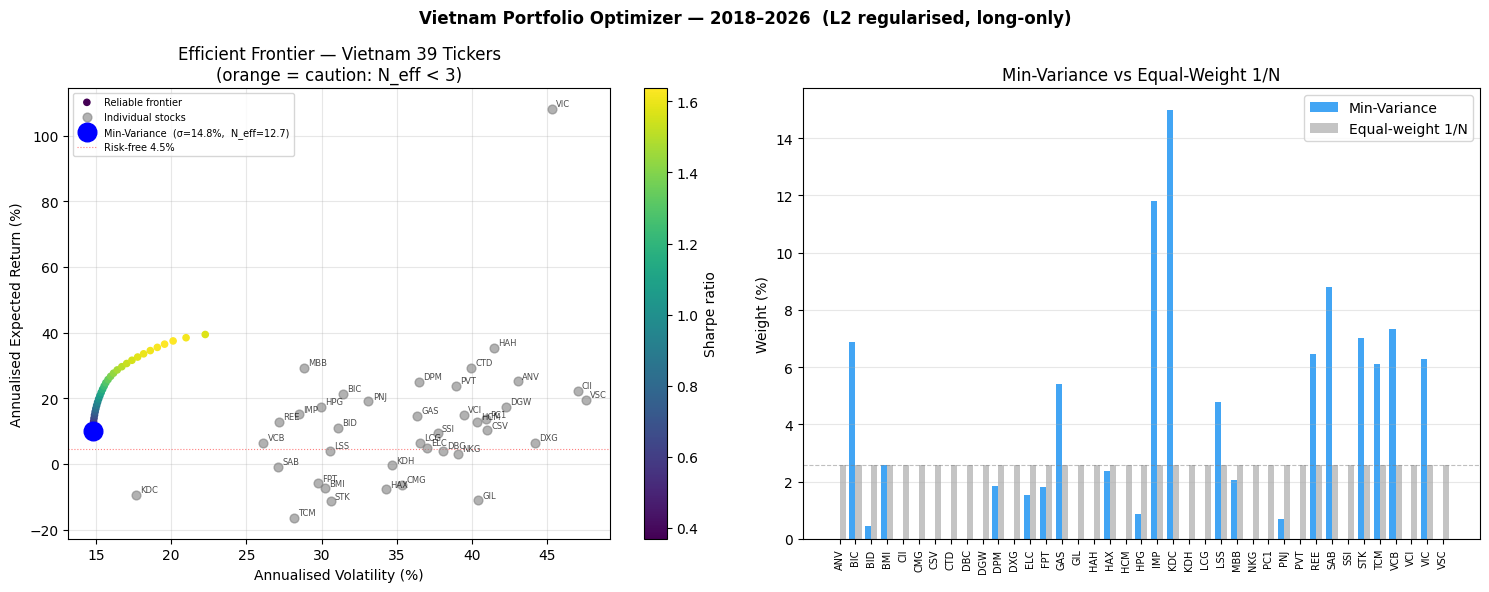


  Target return check: 20.0%
  RELIABLE -- within the diversified frontier zone (N_eff >= 3).

  Target return check: 45.0%
  CAUTION -- above reliable ceiling (39.4%).
    N_eff < 3 — concentration risk high. Consider targeting 39.4%.


False

In [139]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# LEFT — Efficient Frontier with reliable / caution zones
ax = axes[0]

if reliable_mask.sum() > 0:
    sc = ax.scatter(
        F_risk[reliable_mask] * 100, F_ret[reliable_mask] * 100,
        c=F_sr[reliable_mask], cmap='viridis', s=20, zorder=2,
        label='Reliable frontier'
    )
    plt.colorbar(sc, ax=ax, label='Sharpe ratio')

if (~reliable_mask).sum() > 0:
    ax.scatter(
        F_risk[~reliable_mask] * 100, F_ret[~reliable_mask] * 100,
        color='orange', s=25, zorder=2, alpha=0.7, marker='x',
        label=f'Caution zone  (N_eff < 3, >{ret_reliable_max*100:.0f}%)'
    )
    ax.axhline(
        ret_reliable_max * 100, color='orange', ls=':', lw=1.2, alpha=0.8,
        label=f'Reliable ceiling  {ret_reliable_max*100:.1f}%'
    )

ax.scatter(vols * 100, mu * 100, color='grey', alpha=0.6, s=40, zorder=3,
           label='Individual stocks')
for i, tk in enumerate(tickers):
    ax.annotate(tk, (vols[i]*100, mu[i]*100),
                fontsize=6, alpha=0.7, xytext=(3, 2), textcoords='offset points')

ax.scatter(risk_mv*100, ret_mv*100, color='blue', s=180, zorder=5,
           label=f'Min-Variance  (σ={risk_mv*100:.1f}%,  N_eff={1/(w_mv**2).sum():.1f})')

ax.axhline(RF * 100, color='red', lw=0.8, linestyle=':', alpha=0.5,
           label=f'Risk-free {RF*100:.1f}%')
ax.set_xlabel('Annualised Volatility (%)')
ax.set_ylabel('Annualised Expected Return (%)')
ax.set_title('Efficient Frontier — Vietnam 39 Tickers\n(orange = caution: N_eff < 3)')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# RIGHT — Min-Variance weights vs equal-weight benchmark
ax2 = axes[1]
x     = np.arange(n)
width = 0.38
w_eq  = np.ones(n) / n

ax2.bar(x - width/2, w_mv * 100, width, color='#2196F3', label='Min-Variance', alpha=0.85)
ax2.bar(x + width/2, w_eq * 100, width, color='#9E9E9E', label='Equal-weight 1/N', alpha=0.6)
ax2.axhline(100/n, color='grey', lw=0.8, linestyle='--', alpha=0.5)
ax2.set_xticks(x)
ax2.set_xticklabels(tickers, rotation=90, fontsize=7)
ax2.set_ylabel('Weight (%)')
ax2.set_title('Min-Variance vs Equal-Weight 1/N')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('Vietnam Portfolio Optimizer — 2018–2026  (L2 regularised, long-only)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

check_target_return(0.20)
check_target_return(0.45)

---
## Validation — 4-Layer Quality Check

Portfolio optimizers produce mathematically correct answers that can still be financially meaningless.  
This is called the **error maximizer problem** (Michaud 1989): the KKT solver treats noisy μ and Σ estimates as exact truth, then amplifies small estimation errors into extreme weights.

Four layers to detect this:

| Layer | What it checks | What failure looks like |
|---|---|---|
| **1 — Mathematical** | KKT constraints hold exactly | Weights ≠ 1, achieved return ≠ target |
| **2 — Economic** | Results are financially plausible | Gross leverage > 300%, short positions in illiquid stocks |
| **3 — Out-of-sample** | Train-period weights work on unseen data | In-sample Sharpe 2.0, out-of-sample Sharpe −0.3 |
| **4 — Benchmark** | Optimizer beats the naive 1/N portfolio | Equal-weight beats optimized (classic Markowitz failure) |

Layers 1–2 detect bugs and numerical issues. Layers 3–4 detect overfitting to historical noise.

In [140]:
def check(label, passed, detail=''):
    status = 'PASS' if passed else 'FAIL'
    print(f'  {status}  {label:<45}  {detail}')

# LAYER 1 — Mathematical sanity
print('LAYER 1 -- Mathematical Sanity')
print('─' * 62)

check('Min-var weights sum to 1',
      abs(w_mv.sum() - 1.0) < 1e-8,
      f'sum = {w_mv.sum():.10f}')

tol = 1e-6
check('Min-var achieved return matches frontier',
      abs(float(mu @ w_mv) - ret_mv) < tol,
      f'diff = {abs(float(mu @ w_mv) - ret_mv):.2e}')

min_eig = np.linalg.eigvalsh(Sigma).min()
check('Sigma is positive semi-definite (all eigenvalues >= 0)',
      min_eig >= -1e-10,
      f'min eigenvalue = {min_eig:.4e}')

Q   = np.load(os.path.join(PROCESSED_DIR, 'eigenvectors.npy'))
Lam = np.diag(eigenvalues)
recon_err = np.max(np.abs(Sigma - Q @ Lam @ Q.T))
check('Reconstruction ||Sigma - Q*Lambda*Qt||_inf < 1e-10',
      recon_err < 1e-10,
      f'error = {recon_err:.2e}')

idx_mv_layer = np.argmin(F_risk)
upper_half = F_ret[idx_mv_layer:]
monotone   = np.all(np.diff(upper_half) >= -1e-8)
check('Frontier upper branch is monotone increasing',
      monotone,
      f'(checked {len(upper_half)} points)')

min_frontier_risk_at_same_return = []
for i in range(n):
    closest = np.argmin(np.abs(F_ret - mu[i]))
    min_frontier_risk_at_same_return.append(F_risk[closest])
all_outside = np.all(vols >= np.array(min_frontier_risk_at_same_return) - 1e-4)
check('All individual stocks lie on or outside the frontier',
      all_outside,
      f'({n} stocks checked)')

print()

# LAYER 2 — Economic plausibility
print('LAYER 2 -- Economic Plausibility')
print('─' * 62)

mv_beats_all     = np.all(risk_mv <= vols + 1e-6)
worst_stock_vol  = vols.max()
check('Min-var sigma <= all individual stock sigma',
      mv_beats_all,
      f'min-var sigma={risk_mv*100:.2f}%  vs  worst stock={worst_stock_vol*100:.2f}%')

check('Min-var gross exposure <= 1.0  (long-only, no leverage)',
      gross_mv <= 1.0 + 1e-6,
      f'sum|w| = {gross_mv:.4f}')

max_w_mv = np.abs(w_mv).max()
MAX_WEIGHT_CHECK = 0.15
check(f'Min-var max position <= {MAX_WEIGHT_CHECK*100:.0f}%',
      max_w_mv <= MAX_WEIGHT_CHECK + 1e-4,
      f'max |w| = {max_w_mv*100:.2f}%  ({tickers[np.abs(w_mv).argmax()]})')

mu_ok  = np.all((mu > -0.5) & (mu < 2.0))
vol_ok = np.all((vols > 0.05) & (vols < 2.0))
check('All mu in plausible range  (-50% to +200% annual)',
      mu_ok,
      f'range: [{mu.min()*100:.1f}%, {mu.max()*100:.1f}%]')
check('All sigma in plausible range  (5% to 200% annual)',
      vol_ok,
      f'range: [{vols.min()*100:.1f}%, {vols.max()*100:.1f}%]')

hhi_mv = float((w_mv**2).sum())
hhi_eq = 1.0 / n
print(f'\n  Weight concentration (HHI — lower = more diversified):')
print(f'    Equal-weight benchmark : {hhi_eq:.4f}  (1/N = 1/{n})')
print(f'    Min-variance           : {hhi_mv:.4f}  N_eff = {1/hhi_mv:.1f}  {"well diversified" if hhi_mv < 0.15 else "concentrated"}')

LAYER 1 -- Mathematical Sanity
──────────────────────────────────────────────────────────────
  PASS  Min-var weights sum to 1                       sum = 1.0000000000
  PASS  Min-var achieved return matches frontier       diff = 0.00e+00
  PASS  Sigma is positive semi-definite (all eigenvalues >= 0)  min eigenvalue = 2.0752e-02
  PASS  Reconstruction ||Sigma - Q*Lambda*Qt||_inf < 1e-10  error = 2.50e-16
  PASS  Frontier upper branch is monotone increasing   (checked 31 points)
  PASS  All individual stocks lie on or outside the frontier  (39 stocks checked)

LAYER 2 -- Economic Plausibility
──────────────────────────────────────────────────────────────
  PASS  Min-var sigma <= all individual stock sigma    min-var sigma=14.81%  vs  worst stock=47.54%
  PASS  Min-var gross exposure <= 1.0  (long-only, no leverage)  sum|w| = 1.0000
  PASS  Min-var max position <= 15%                    max |w| = 15.00%  (KDC)
  PASS  All mu in plausible range  (-50% to +200% annual)  range: [-16.6%, 108

In [141]:
# LAYER 3 -- Walk-forward out-of-sample test  (long-only)
print('LAYER 3 -- Walk-Forward Out-of-Sample Test  (long-only QP)')
print('─' * 62)

from scipy.optimize import minimize as _minimize

MAX_WEIGHT  = 0.15
TRAIN_END   = '2023-12-31'
TEST_START  = '2024-01-01'

RAW_DIR   = os.path.join('portfolio_data', 'raw', 'prices')
csv_files = sorted(f for f in os.listdir(RAW_DIR) if f.endswith('.csv'))
tickers_  = [f.replace('.csv', '') for f in csv_files]

frames = {s: pd.read_csv(os.path.join(RAW_DIR, f'{s}.csv'),
                          index_col='Date', parse_dates=['Date'])['Close']
          for s in tickers_}
prices_all   = pd.DataFrame(frames).sort_index().dropna(how='all')
prices_train = prices_all[prices_all.index <= TRAIN_END].ffill(limit=5).dropna()
prices_test  = prices_all[prices_all.index >= TEST_START].ffill(limit=5).dropna()
R_train = prices_train.pct_change().dropna()
R_test  = prices_test.pct_change().dropna()

T_tr, n_a = R_train.shape
T_te, _   = R_test.shape
print(f'  Train : {R_train.index[0].date()} -> {R_train.index[-1].date()}  ({T_tr} days)')
print(f'  Test  : {R_test.index[0].date()}  -> {R_test.index[-1].date()}   ({T_te} days)')
print(f'  Train T/N : {T_tr/n_a:.1f}')

# Train-period EWMA mu and Sigma
HALFLIFE_TR = 252
LAMBDA_TR   = 0.05
mu_tr       = R_train.ewm(halflife=HALFLIFE_TR).mean().iloc[-1].values * 252
_ecov       = R_train.ewm(halflife=HALFLIFE_TR).cov()
Sigma_tr    = _ecov.loc[_ecov.index.get_level_values(0)[-1]].values * 252
Sigma_tr_reg = Sigma_tr + LAMBDA_TR * np.eye(n_a)

# Global min-variance on training data
gmv_tr = _minimize(
    fun         = lambda w: w @ Sigma_tr_reg @ w,
    x0          = np.ones(n_a) / n_a,
    method      = 'SLSQP',
    bounds      = [(0.0, MAX_WEIGHT)] * n_a,
    constraints = [{'type': 'eq', 'fun': lambda w: w.sum() - 1.0}],
    options     = {'ftol': 1e-10, 'maxiter': 1000},
)
w_mv_tr = gmv_tr.x.clip(0)
w_eq    = np.ones(n_a) / n_a

def portfolio_metrics(w, R, label):
    daily    = R.values @ w
    ret_ann  = daily.mean() * 252
    risk_ann = daily.std()  * np.sqrt(252)
    sr       = (ret_ann - RF) / risk_ann if risk_ann > 0 else float('nan')
    cum_ret  = (1 + pd.Series(daily)).prod() - 1
    return {'label': label, 'ann_ret': ret_ann, 'ann_vol': risk_ann,
            'sharpe': sr, 'cum_ret': cum_ret}

results = [
    portfolio_metrics(w_mv_tr, R_train, 'Min-Var      (in-sample)'),
    portfolio_metrics(w_mv_tr, R_test,  'Min-Var      (out-of-sample)'),
    portfolio_metrics(w_eq,    R_train, 'Equal-weight (in-sample)'),
    portfolio_metrics(w_eq,    R_test,  'Equal-weight (out-of-sample)'),
]

print(f"\n  {'Portfolio':<35}  {'Ann. Return':>12}  {'Volatility':>12}  {'Sharpe':>8}  {'Cum. Return':>12}")
print(f"  {'─'*85}")
for m in results:
    print(f"  {m['label']:<35}  {m['ann_ret']*100:>11.2f}%  {m['ann_vol']*100:>11.2f}%  "
          f"{m['sharpe']:>8.3f}  {m['cum_ret']*100:>11.2f}%")

m_mv_is,  m_mv_oos  = results[0], results[1]
m_eq_is,  m_eq_oos  = results[2], results[3]

print(f'\n  Degradation check (IS Sharpe -> OOS Sharpe):')
for name, is_, oos_ in [('Min-Var', m_mv_is, m_mv_oos), ('Equal-weight', m_eq_is, m_eq_oos)]:
    drop = is_['sharpe'] - oos_['sharpe']
    flag = 'Acceptable' if abs(drop) < 0.8 else 'Large drop -- possible overfitting'
    print(f'    {name:<14}  IS={is_["sharpe"]:+.3f}  OOS={oos_["sharpe"]:+.3f}  drop={drop:+.3f}  {flag}')

LAYER 3 -- Walk-Forward Out-of-Sample Test  (long-only QP)
──────────────────────────────────────────────────────────────
  Train : 2018-01-03 -> 2023-12-29  (1497 days)
  Test  : 2024-01-03  -> 2026-04-24   (592 days)
  Train T/N : 38.4

  Portfolio                             Ann. Return    Volatility    Sharpe   Cum. Return
  ─────────────────────────────────────────────────────────────────────────────────────
  Min-Var      (in-sample)                   10.52%        16.39%     0.367        72.36%
  Min-Var      (out-of-sample)               13.97%        14.78%     0.640        35.29%
  Equal-weight (in-sample)                   16.05%        22.97%     0.503       121.43%
  Equal-weight (out-of-sample)               13.85%        19.61%     0.477        32.28%

  Degradation check (IS Sharpe -> OOS Sharpe):
    Min-Var         IS=+0.367  OOS=+0.640  drop=-0.273  Acceptable
    Equal-weight    IS=+0.503  OOS=+0.477  drop=+0.026  Acceptable


LAYER 4 -- Optimizer vs Equal-Weight Benchmark
──────────────────────────────────────────────────────────────
  Test period cumulative returns (2024-01-01 -> 2026-04-24):
    Min-Variance  : +35.29%
    Equal-Weight  : +32.28%

  Min-Variance beats 1/N?  Yes

  Min-Variance adds value beyond naive diversification out-of-sample.


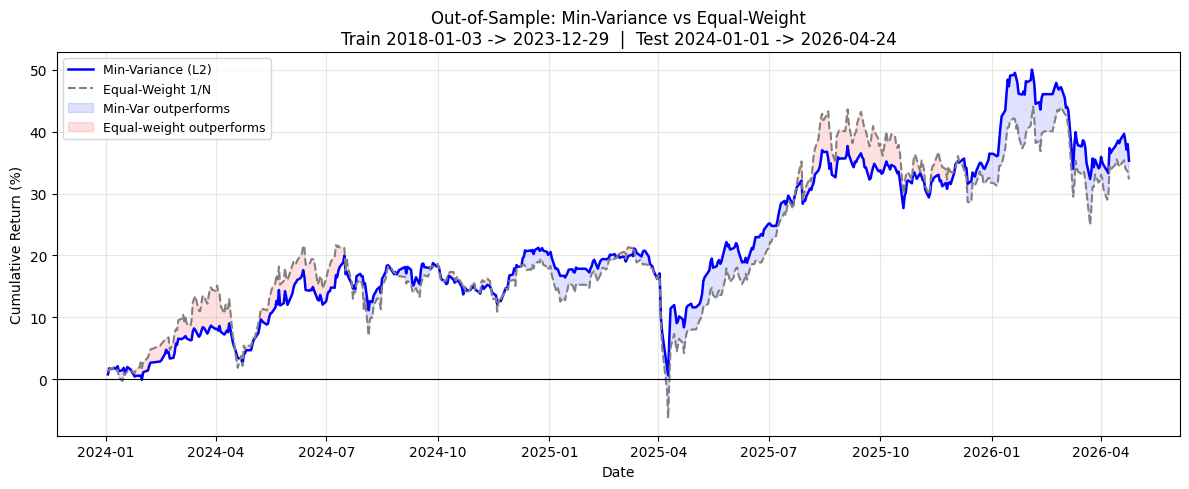


  VALIDATION SUMMARY
  Layer 1 (Math sanity)  : weights sum to 1, Sigma PSD, reconstruction error
  Layer 2 (Economic)     : min-var sigma <= all stocks  |  gross exposure = 1.000x
  Layer 3 (OOS Sharpe)   : IS=+0.367  OOS=+0.640  drop=-0.273
  Layer 4 (Benchmark)    : Min-Var beats 1/N  out-of-sample


In [142]:
# LAYER 4 -- Cumulative return chart: Min-Var vs equal-weight benchmark
# DeMiguel et al. (2009): equal-weight 1/N often beats Markowitz OOS.
# If equal-weight wins here, it signals the optimizer is chasing noisy mu.
print('LAYER 4 -- Optimizer vs Equal-Weight Benchmark')
print('─' * 62)

def cumulative_curve(w, R):
    daily = R.values @ w
    return (1 + pd.Series(daily, index=R.index)).cumprod()

curve_mv = cumulative_curve(w_mv_tr, R_test)
curve_eq = cumulative_curve(w_eq,    R_test)

final_mv = curve_mv.iloc[-1] - 1
final_eq = curve_eq.iloc[-1] - 1

print(f'  Test period cumulative returns ({TEST_START} -> {R_test.index[-1].date()}):')
print(f'    Min-Variance  : {final_mv*100:+.2f}%')
print(f'    Equal-Weight  : {final_eq*100:+.2f}%')

optimizer_wins = final_mv > final_eq
print(f'\n  Min-Variance beats 1/N?  {"Yes" if optimizer_wins else "No -- equal-weight wins"}')

if not optimizer_wins:
    print(f'\n  Equal-weight outperforms out-of-sample.')
    print(f'  This is consistent with the Michaud error-maximizer critique.')
    print(f'  L2 regularisation reduces but does not eliminate this effect.')
else:
    print(f'\n  Min-Variance adds value beyond naive diversification out-of-sample.')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(curve_mv.index, (curve_mv - 1) * 100, label='Min-Variance (L2)',
        color='blue', lw=1.8)
ax.plot(curve_eq.index, (curve_eq - 1) * 100, label='Equal-Weight 1/N',
        color='grey', lw=1.5, linestyle='--')
ax.axhline(0, color='black', lw=0.8)
ax.fill_between(curve_eq.index,
                (curve_mv - 1) * 100, (curve_eq - 1) * 100,
                where=(curve_mv >= curve_eq),
                alpha=0.12, color='blue',  label='Min-Var outperforms')
ax.fill_between(curve_eq.index,
                (curve_mv - 1) * 100, (curve_eq - 1) * 100,
                where=(curve_mv < curve_eq),
                alpha=0.12, color='red',   label='Equal-weight outperforms')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return (%)')
ax.set_title(f'Out-of-Sample: Min-Variance vs Equal-Weight\n'
             f'Train {R_train.index[0].date()} -> {R_train.index[-1].date()}  |  '
             f'Test {TEST_START} -> {R_test.index[-1].date()}')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n{'='*62}")
print(f'  VALIDATION SUMMARY')
print(f"{'='*62}")
print(f'  Layer 1 (Math sanity)  : weights sum to 1, Sigma PSD, reconstruction error')
print(f'  Layer 2 (Economic)     : min-var sigma <= all stocks  |  gross exposure = {gross_mv:.3f}x')
print(f'  Layer 3 (OOS Sharpe)   : IS={m_mv_is["sharpe"]:+.3f}  OOS={m_mv_oos["sharpe"]:+.3f}  '
      f'drop={m_mv_is["sharpe"]-m_mv_oos["sharpe"]:+.3f}')
print(f'  Layer 4 (Benchmark)    : Min-Var {"beats" if optimizer_wins else "loses to"} 1/N  out-of-sample')

## Live Data Refresh — Daily Incremental Update

**When to run:** HOSE/HNX close at **3:00 PM ICT (UTC+7)**. yfinance data lands ~15–30 min later.
- Recommended trigger: **3:30 PM ICT** daily (Mon–Fri)
- As a Linux/Mac cron job: `30 8 * * 1-5  cd /path/to/project && jupyter nbconvert --to notebook --execute LinearCode.ipynb`
- Weekend or VN public holiday → yfinance returns empty → refresh is a no-op

**Architecture — three-layer separation:**

```
Raw CSVs (portfolio_data/raw/prices/)
   ↓  [daily refresh — this cell]
Processed (portfolio_data/processed/)   ← recompute Σ, μ, eigendecomposition
   ↓  [on each web request]
KKT solve → optimal weights → API response
```

**How incremental refresh works:**
1. Read the last saved date from each ticker's existing CSV
2. Download only the **delta** (`last_date + 1 → today`) — no full re-download
3. Forward-fill gaps ≤ 5 days (same rule as initial load)
4. Append new rows only — idempotent (safe to run twice in one day)

In [128]:
import yfinance as yf
import pandas as pd
import os, time, json
from datetime import date, timedelta, datetime

RAW_DIR       = os.path.join("portfolio_data", "raw", "prices")
PROCESSED_DIR = os.path.join("portfolio_data", "processed")
FFILL_LIMIT   = 5

PIPELINE_START = time.time()
print("╔══════════════════════════════════════════════════════╗")
print("║         DAILY DATA REFRESH PIPELINE                 ║")
print("╚══════════════════════════════════════════════════════╝")
print(f"  Started : {datetime.now().strftime('%Y-%m-%d  %H:%M:%S')}\n")

# ──────────────────────────────────────────────────────────
# PIPELINE STEP 1 / 4 — Discover tracked tickers & last dates
# ──────────────────────────────────────────────────────────
print("PIPELINE 1 / 4 — Scan raw CSVs")
print("─" * 50)
t0 = time.time()

csv_files = sorted(f for f in os.listdir(RAW_DIR) if f.endswith(".csv"))
tracked   = {}   # stock → last saved date (datetime.date)

for fname in csv_files:
    stock = fname.replace(".csv", "")
    df    = pd.read_csv(os.path.join(RAW_DIR, fname),
                        index_col="Date", parse_dates=["Date"])
    tracked[stock] = df.index.max().date()

oldest_last  = min(tracked.values())
newest_last  = max(tracked.values())
fetch_start  = oldest_last + timedelta(days=1)
fetch_end    = date.today()

print(f"  Tickers tracked  : {len(tracked)}")
print(f"  Earliest last row: {oldest_last}  ({sum(1 for v in tracked.values() if v == oldest_last)} tickers)")
print(f"  Latest last row  : {newest_last}")
print(f"  Fetch window     : {fetch_start}  →  {fetch_end}")

if fetch_start > fetch_end:
    print(f"\n  ✓ Already up to date — nothing to fetch.")
    print(f"\n  Pipeline finished in {time.time()-PIPELINE_START:.2f}s")
else:
    print(f"  ✓ Step 1 done  ({time.time()-t0:.2f}s)\n")

    # ──────────────────────────────────────────────────────
    # PIPELINE STEP 2 / 4 — Fetch delta from yfinance
    # ──────────────────────────────────────────────────────
    print("PIPELINE 2 / 4 — Fetch delta from yfinance")
    print("─" * 50)
    t0 = time.time()

    tickers_vn      = [s + ".VN" for s in tracked]
    ticker_to_stock = {s + ".VN": s for s in tracked}

    print(f"  Requesting {len(tickers_vn)} tickers  ({fetch_start} → {fetch_end}) ...")
    raw_delta = yf.download(
        tickers_vn,
        start=str(fetch_start),
        end=str(fetch_end + timedelta(days=1)),   # yfinance end is exclusive
        auto_adjust=True,
        threads=True,
        progress=False,
    )

    if raw_delta.empty:
        print(f"  ⚠  No data returned — market holiday or weekend.")
        print(f"  Pipeline finished in {time.time()-PIPELINE_START:.2f}s")
    else:
        close_delta = raw_delta["Close"].rename(columns=ticker_to_stock)
        close_delta = close_delta.dropna(how="all")        # drop pure holiday rows
        close_delta = close_delta.ffill(limit=FFILL_LIMIT)

        new_dates = list(close_delta.index.date)
        print(f"  New trading dates  : {len(new_dates)}")
        for d_ in new_dates:
            print(f"    {d_}")
        non_null = (close_delta.notna().sum(axis=1))
        print(f"  Tickers with data  : {non_null.min()}–{non_null.max()} per new date")
        print(f"  ✓ Step 2 done  ({time.time()-t0:.2f}s)\n")

        # ──────────────────────────────────────────────────
        # PIPELINE STEP 3 / 4 — Append new rows to raw CSVs
        # ──────────────────────────────────────────────────
        print("PIPELINE 3 / 4 — Append to raw CSVs")
        print("─" * 50)
        t0 = time.time()

        result = {}   # stock → rows appended
        for stock in tracked:
            if stock not in close_delta.columns:
                result[stock] = 0
                continue

            new_data = (close_delta[[stock]]
                        .rename(columns={stock: "Close"})
                        .dropna())
            new_rows = new_data[new_data.index.date > tracked[stock]]

            if new_rows.empty:
                result[stock] = 0
                continue

            path = os.path.join(RAW_DIR, f"{stock}.csv")
            new_rows.index.name = "Date"
            new_rows.to_csv(path, mode="a", header=False)
            result[stock] = len(new_rows)

        updated   = {k: v for k, v in result.items() if v > 0}
        unchanged = [k for k, v in result.items() if v == 0]

        print(f"  Updated   : {len(updated)} tickers")
        print(f"  Unchanged : {len(unchanged)} tickers")
        if updated:
            print(f"\n  {'Ticker':<8}  {'Rows added':>10}")
            print(f"  {'─'*22}")
            for stock, n_rows in sorted(updated.items()):
                print(f"  {stock:<8}  {n_rows:>10}")
        if unchanged:
            print(f"\n  Unchanged tickers: {sorted(unchanged)}")
        print(f"  ✓ Step 3 done  ({time.time()-t0:.2f}s)\n")

        # ──────────────────────────────────────────────────
        # PIPELINE STEP 4 / 4 — Recompute processed layer
        # Runs only when at least one ticker was updated.
        # ──────────────────────────────────────────────────
        print("PIPELINE 4 / 4 — Recompute processed layer")
        print("─" * 50)
        t0 = time.time()

        if not updated:
            print("  Skipped — no raw CSVs were changed.")
        else:
            meta_new = build_processed(RAW_DIR, PROCESSED_DIR, verbose=True)
            print(f"\n  Processed layer updated:")
            print(f"    date_end     : {meta_new['date_end']}")
            print(f"    t_days       : {meta_new['t_days']}")
            print(f"    t_n_ratio    : {meta_new['t_n_ratio']}")
            print(f"    last_updated : {meta_new['last_updated']}")
            print(f"  ✓ Step 4 done  ({time.time()-t0:.2f}s)")

        print(f"\n{'═'*56}")
        print(f"  PIPELINE COMPLETE")
        print(f"{'═'*56}")
        print(f"  Total time  : {time.time()-PIPELINE_START:.2f}s")
        print(f"  Raw updated : {len(updated)} / {len(tracked)} tickers")
        if updated:
            print(f"  Optimizer   : ready with data through {meta_new['date_end']}")
        print(f"  Finished    : {datetime.now().strftime('%Y-%m-%d  %H:%M:%S')}")

╔══════════════════════════════════════════════════════╗
║         DAILY DATA REFRESH PIPELINE                 ║
╚══════════════════════════════════════════════════════╝
  Started : 2026-04-25  17:42:29

PIPELINE 1 / 4 — Scan raw CSVs
──────────────────────────────────────────────────
  Tickers tracked  : 39
  Earliest last row: 2026-04-20  (39 tickers)
  Latest last row  : 2026-04-20
  Fetch window     : 2026-04-21  →  2026-04-25
  ✓ Step 1 done  (0.04s)

PIPELINE 2 / 4 — Fetch delta from yfinance
──────────────────────────────────────────────────
  Requesting 39 tickers  (2026-04-21 → 2026-04-25) ...
  New trading dates  : 4
    2026-04-21
    2026-04-22
    2026-04-23
    2026-04-24
  Tickers with data  : 39–39 per new date
  ✓ Step 2 done  (1.62s)

PIPELINE 3 / 4 — Append to raw CSVs
──────────────────────────────────────────────────
  Updated   : 39 tickers
  Unchanged : 0 tickers

  Ticker    Rows added
  ──────────────────────
  ANV                4
  BIC                4
  BID 